# ZnMgSe analysis

In [ ]:
# reloads python code if it changes
%reload_ext autoreload
%autoreload 2
# use the interactive widget view for matplotlib
%matplotlib widget

# import statements
import numpy as np
from numpy.typing import NDArray
from matplotlib import pyplot as plt

## Data loading & preprocessing

First, we load the data. If you're interested in the details, navigate to the function definition for `load_foldslice`.

In [ ]:
from util.io import load_foldslice

obj, obj_sampling = load_foldslice("data/ZnSe.mat")

print(f"type(obj): {type(obj)}")
print(f"obj dtype: {obj.dtype} shape: {obj.shape}")

Next, we calculate the phase from the complex object (`np.angle`) and remove the affine ramp

In [ ]:
from util.filter import remove_linear_ramp

phase = remove_linear_ramp(np.angle(obj))

It's always a good idea to plot the phase stack.
Use the rectangle tool in the plot to zoom into a subregion. Observe where the crystalline region begins and ends

In [ ]:
from util.plot import plot_stack

fig, axs = plot_stack(phase, cmap='magma', colorbar=True)
fig.set_size_inches(9, 3)

We can also plot contrast as a function of depth:

In [ ]:
contrast = np.std(phase, axis=(-1, -2))

fig, ax = plt.subplots(figsize=(6, 3))
ax.set_ylabel("Contrast")
ax.set_xlabel("Slice #")

ax.bar(np.arange(len(phase)), contrast, width=0.9)

plt.show()

Question: Does this dataset look under- or over-regularized in depth?

Let's select only the center slices, and average:

In [ ]:
phase_crop = phase[8:23]

mean_phase = np.mean(phase_crop, axis=0)
mean_phase -= np.nanquantile(mean_phase, 0.1)
mean_int = np.mean(np.abs(obj)**2, axis=0)

fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, constrained_layout=True)
fig.set_size_inches(6, 3)

fig.suptitle("Mean image")
fig.colorbar(axs[0].imshow(mean_phase), label="Mean phase [rad]", shrink=0.7)
fig.colorbar(axs[1].imshow(mean_int, vmax=1.0), label="Mean intensity", shrink=0.7)
plt.show()

## Peak finding and integration

For the rest of this notebook, we'll look at the 2D mean phase.

To find atom columns in the image, we use normalized cross correlation:

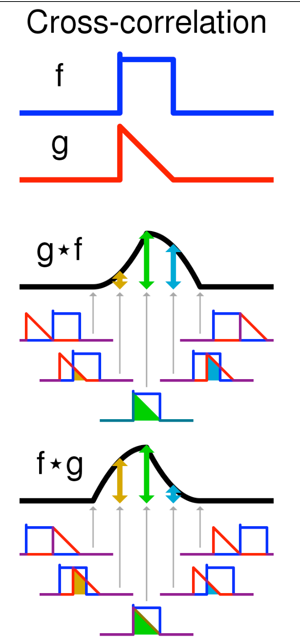

In [ ]:
from util.peaks import find_peaks

template_sigma = 1.5  # std. deviation of Gaussian template (px)
threshold_corr = 0.6  # threshold normalized cross correlation to consider it a peak

# check the definition of this function to see the details
(cross_corr, peaks) = find_peaks(mean_phase, template_sigma, threshold_corr, min_distance=3)

fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)
axs[0].set_title("Mean phase")
axs[0].imshow(mean_phase)

axs[1].set_title("Cross correlation")
axs[1].imshow(cross_corr, cmap='bwr', vmin=-1.0, vmax=1.0)

axs[0].scatter(peaks[..., 1], peaks[..., 0], s=2, c='red')
axs[1].scatter(peaks[..., 1], peaks[..., 0], s=2, c='red')

plt.show()

Now we can begin to extract intensities from the peaks.

You could just take the phase of the image at the peak position, but this tends to be a noisy measurement and very sensitive to the quality of the reconstruction. A more robust method is to integrate circular regions around the peak:

In [ ]:
from util.peaks import integrate_peaks
from matplotlib.colors import Normalize

# integrate in 0.5 angstrom radius
peak_ints = integrate_peaks(mean_phase, peaks, 0.5 / obj_sampling[0])

fig, axs = plt.subplots(ncols=2, constrained_layout=True, gridspec_kw={'width_ratios': [4, 1]})
axs[0].set_axis_off()
axs[1].set_ylabel("Integrated phase (arb.)")

vmin, vmax = float(np.min(peak_ints)), float(np.max(peak_ints))

cmap = plt.get_cmap('magma')
norm = Normalize(vmin, vmax)

axs[0].imshow(mean_phase, cmap='gray')
axs[0].scatter(peaks[:, 1], peaks[:, 0], s=10, c=peak_ints, cmap=cmap, norm=norm)

hist, bins = np.histogram(peak_ints, 50, range=(vmin, vmax))
bin_heights = bins[1:] - bins[:-1]  # type: ignore
axs[1].barh(bins[:-1], hist, height=bin_heights, align='edge', color=cmap(norm(bins[:-1])))

plt.show()

We can see the Zn/Mg columns and Se columns are well separated in the histogram. Because of this, we can use this integrated phase to distinguish the sites.

First, we identify dumbbells (they're the closest atom pairs). Then, we determine which site is Zn/Mg and which site is Se.

In [ ]:
from scipy.spatial import KDTree
# find dumbbells

dumbbell_length = 1.416  # angstrom

tree = KDTree(peaks)

pairs: NDArray[np.int_] = tree.query_pairs(1.2 * dumbbell_length / obj_sampling[0], output_type='ndarray')  # type: ignore
pair_ints = peak_ints[pairs]

# flip pairs so Zn (lower intensity) is first
pairs = np.where(pair_ints[:, [0]] >= pair_ints[:, [1]], pairs[:, ::-1], pairs)
pair_ints = peak_ints[pairs]

fig, ax = plt.subplots()

ax.imshow(mean_phase, cmap='gray')
ax.scatter(peaks[pairs[:, 0], 1], peaks[pairs[:, 0], 0], s=8, c='blue', label="Zn/Mg")
ax.scatter(peaks[pairs[:, 1], 1], peaks[pairs[:, 1], 0], s=8, c='green', label="Se")

plt.show()

In [ ]:
pairs[1]

`pairs` is a Nx2 array of indices which reference our original peak list. The first column indicates the Zn/Mg site, and the second column indicates the Se site.

Let's make it a little more obvious:

In [ ]:
zn_peaks = peaks[pairs[:, 0]]
se_peaks = peaks[pairs[:, 1]]

zn_peak_ints = peak_ints[pairs[:, 0]]
se_peak_ints = peak_ints[pairs[:, 1]]

print(f"""
zn_peaks shape: {zn_peaks.shape} dtype: {zn_peaks.dtype}
se_peaks shape: {se_peaks.shape} dtype: {se_peaks.dtype}
zn_peak_ints shape: {zn_peak_ints.shape} dtype: {zn_peak_ints.dtype}
se_peak_ints shape: {se_peak_ints.shape} dtype: {se_peak_ints.dtype}
""")

Now we can plot column intensities independently for the Zn/Mg and Se sublattices

In [ ]:
from util.plot import plot_voronoi

fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

axs[0].imshow(mean_phase, cmap='gray')
axs[1].imshow(mean_phase, cmap='gray')

axs[0].set_title("Zn/Mg column intensities")
plot_voronoi(axs[0], zn_peaks[..., 1], zn_peaks[..., 0], zn_peak_ints, mean_phase.shape, cmap='magma', max_r=4.0)
axs[1].set_title("Se intensities")
plot_voronoi(axs[1], se_peaks[..., 1], se_peaks[..., 0], se_peak_ints, mean_phase.shape, cmap='magma', max_r=4.0)

plt.show()

## 2D Gaussian peak fitting

To extract more information about the location, shape, and intensity of the peaks, we fit each peak to a 2D Gaussian function:

$$
I(\vec{r}) = A \exp\left( -\frac{1}{2} (\vec{r} - \vec{p})^{\mathrm{T}}\: \mathbf{\Sigma}^{-1} (\vec{r} - \vec{p}) \right),
$$
where $I(\vec{r})$ is the phase at position $\vec{r}$, $\vec{p}$ is the peak center position, $A$ is the maximum phase of the peak and $\mathbf{\Sigma}$ is a positive-definite covariance matrix indicating the peak spread.

In [ ]:
from util.peaks import fit_2d_peaks

peak_fit, residuals = fit_2d_peaks(mean_phase, peaks, cutout_r=4, sigma=1., use_bg=True)

# some peak fits may have failed (or are cropped at the edge of the image), so we exclude them here.
zn_peak_fit = peak_fit[np.isin(peak_fit['i'], pairs[:, 0])]
se_peak_fit = peak_fit[np.isin(peak_fit['i'], pairs[:, 1])]

fig, ax = plt.subplots()
ax.imshow(residuals)
plt.show()

The residuals plot above shows the result after peak fitting. We should have removed almost all of the atom column intensity from the image.

Let's examine `peak_fit` more closely, it's a structured numpy array, which acts like a table:

In [ ]:
print(f"type: {type(peak_fit)} shape: {peak_fit.shape}\ndtype: {peak_fit.dtype}")

The 'dtype' indicates the values present in each row of the table. `'peak'` is the maximum phase, and `'amp'` is the total integrated phase. `'sigma'`, `'sigma_x'`, `'sigma_1'`, etc. are measures of peak spread, and `'bg'` is background intensity.

We can select a row to get the result for one atom column:

In [ ]:
print(peak_fit[0])
# or, for instance, the standard deviation
print(f"sigma: {peak_fit[0]['sigma']}")

Alternatively, we can select columns by indexing with their name

In [ ]:
peak_fit['peak']

Let's plot the results.

First, the peak phase:

In [ ]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

axs[0].imshow(mean_phase, cmap='gray')
axs[1].imshow(mean_phase, cmap='gray')

axs[0].set_title("Zn/Mg peak phase")
plot_voronoi(axs[0], zn_peak_fit['x'], zn_peak_fit['y'], zn_peak_fit['peak'], mean_phase.shape, cmap='magma')
axs[1].set_title("Se peak phase")
plot_voronoi(axs[1], se_peak_fit['x'], se_peak_fit['y'], se_peak_fit['peak'], mean_phase.shape, cmap='magma')

plt.show()

Then, the integrated phase:

In [ ]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

axs[0].imshow(mean_phase, cmap='gray')
axs[1].imshow(mean_phase, cmap='gray')

axs[0].set_title("Zn/Mg integrated phase")
plot_voronoi(axs[0], zn_peak_fit['x'], zn_peak_fit['y'], zn_peak_fit['amp'], mean_phase.shape, cmap='magma')
axs[1].set_title("Se integrated phase")
plot_voronoi(axs[1], se_peak_fit['x'], se_peak_fit['y'], se_peak_fit['amp'], mean_phase.shape, cmap='magma')

plt.show()

And finally, the peak standard deviation:

In [ ]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

axs[0].imshow(mean_phase, cmap='gray')
axs[1].imshow(mean_phase, cmap='gray')

axs[0].set_title("Zn/Mg peak std. dev")
plot_voronoi(axs[0], zn_peak_fit['x'], zn_peak_fit['y'], zn_peak_fit['sigma'], mean_phase.shape, cmap='magma')
axs[1].set_title("Se peak std. dev")
plot_voronoi(axs[1], se_peak_fit['x'], se_peak_fit['y'], se_peak_fit['sigma'], mean_phase.shape, cmap='magma')

plt.show()

Question: What is going on?

Mg: Z=12
Zn: Z=30
Se: Z=24

Mg is expected from DFT to preferentially occupy the stacking fault

## Take-home Exercises

1. Plot the Zn to Se intensity ratio

2. Analyze the Zn/Mg peak phase as a function of depth

2. Select the dumbbells (Zn/Mg & Se) along the stacking fault. Compare the peak phase of the Zn/Mg columns at the fault vs. the rest of the crystal